## Map-reduce

In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

## Problem

Map-reduce operations are essential for efficient task decomposition and parallel processing.

It has two phases:

(1) Map - Break a task into smaller sub-tasks, processing each sub-task in parallel.

(2) Reduce - Aggregate the results across all of the completed, parallelized sub-tasks.

Let's design a system that will do two things:

(1) Map - Create a set of jokes about a topic.

(2) Reduce - Pick the best joke from the list.

We'll use an LLM to do the job generation and selection.

In [ ]:

from langchain_openai import ChatOpenAI

# Prompts we will use
subjects_prompt = """Generate a list of 3 sub-topics that are all related to this overall topic: {topic}."""
joke_prompt = """Generate a joke about {subject}"""
best_joke_prompt = """Below are a bunch of jokes about {topic}. Select the best one! Return the ID of the best one, starting 0 as the ID for the first joke. Jokes: \n\n  {jokes}"""

# LLM
model = ChatOpenAI(model="gpt-4o", temperature=0) 

## State

### Parallelizing joke generation
First, let's define the entry point of the graph that will:

1. Take a user input topic
2. Produce a list of joke topics from it
3. Send each joke topic to our above joke generation node

Our state has a jokes key, which will accumulate jokes from parallelized joke generation


In [ ]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel

class Subjects(BaseModel):
    subjects: list[str]

class BestJoke(BaseModel):
    id: int
    
class OverallState(TypedDict):
    topic: str
    subjects: list
    jokes: Annotated[list, operator.add]
    best_selected_joke: str

In [ ]:
def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = model.with_structured_output(Subjects).invoke(prompt)
    return {"subjects": response.subjects}

Here is the magic: we use the Send to create a joke for each subject.

This is very useful! It can automatically parallelize joke generation for any number of subjects.

1. generate_joke: the name of the node in the graph
2. {"subject": s}: the state to send

Send allow you to pass any state that you want to generate_joke! It does not have to align with OverallState.

In this case, generate_joke is using its own internal state, and we can populate this via Send.

In [ ]:
from langgraph.types import Send
def continue_to_jokes(state: OverallState):
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

## Joke generation (map)
Now, we just define a node that will create our jokes, generate_joke!

We write them back out to jokes in OverallState!

This key has a reducer that will combine lists.

In [ ]:
class JokeState(TypedDict):
    subject: str

class Joke(BaseModel):
    joke: str

def generate_joke(state: JokeState):
    prompt = joke_prompt.format(subject=state["subject"])
    response = model.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [response.joke]}

## Best joke selection (reduce)

In [ ]:
def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}

## Compile

In [ ]:
from IPython.display import Image
from langgraph.graph import END, StateGraph, START

# Construct the graph: here we put everything together to construct our graph
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
graph.add_node("generate_joke", generate_joke)
graph.add_node("best_joke", best_joke)
graph.add_edge(START, "generate_topics")
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
graph.add_edge("generate_joke", "best_joke")
graph.add_edge("best_joke", END)

# Compile the graph
app = graph.compile()
Image(app.get_graph().draw_mermaid_png())

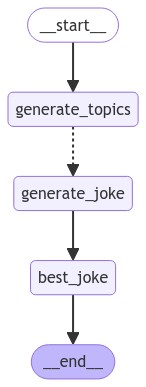

In [ ]:
# Call the graph: here we call it to generate a list of jokes
for s in app.stream({"topic": "animals"}):
    print(s)

{'generate_topics': {'subjects': ['mammals', 'reptiles', 'birds']}}
{'generate_joke': {'jokes': ["Why don't mammals ever get lost? Because they always follow their 'instincts'!"]}}
{'generate_joke': {'jokes': ["Why don't alligators like fast food? Because they can't catch it!"]}}
{'generate_joke': {'jokes': ["Why do birds fly south for the winter? Because it's too far to walk!"]}}
{'best_joke': {'best_selected_joke': "Why don't alligators like fast food? Because they can't catch it!"}}
